<a href="https://colab.research.google.com/github/YikeCahya/PCVK_Ganjil_2026/blob/main/Week02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Studi Kasus 2**: Marketplace seperti Tokopedia dan Shopee menampilkan foto
produk dalam bingkai persegi 1:1. Foto penjual yang berukuran potrait atau
lanskap akan terpotong atau terlihat tidak proporsional bila diunggah begitu saja.
Bangun program yang mengubah foto berukuran apa pun menjadi thumbnail
persegi tanpa mengubah rasio aslinya, dengan sisa ruang diisi kanvas berwarna.
Dalam hal ini, rasio asli tetap terjaga, citra terpasang tepat di tengah kanvas,
tambahkan logo nama toko berukuran proporsional pada gambar.

In [42]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [43]:
img = cv.imread('Gaun.jpeg')
logo = cv.imread('logo_polinema.png')

# Konversi ke RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
logo_rgb = cv.cvtColor(logo, cv.COLOR_BGR2RGB)

In [44]:
def buat_thumbnail_dengan_logo(citra, logo_img, warna_latar=(210, 230, 245)):
    h, w = citra.shape[:2]

    # Tentukan ukuran sisi persegi mengikuti dimensi terbesar
    sisi = max(h, w)

    # Buat kanvas persegi 1:1 dengan NumPy
    kanvas = np.full((sisi, sisi, 3), warna_latar, dtype=np.uint8)

    # Hitung posisi tengah dan tempelkan citra (slicing)
    offset_y = (sisi - h) // 2
    offset_x = (sisi - w) // 2
    kanvas[offset_y:offset_y + h, offset_x:offset_x + w] = citra

    # Resize logo secara proporsional (lebar logo = 18% sisi kanvas)
    logo_w_baru = int(sisi * 0.18)
    lh, lw = logo_img.shape[:2]
    logo_h_baru = int(logo_w_baru * (lh / lw))
    logo_resized = cv.resize(logo_img, (logo_w_baru, logo_h_baru), interpolation=cv.INTER_AREA)

    # Tempelkan logo di pojok kiri atas (margin adaptif 3%)
    margin = int(sisi * 0.03)
    y1, y2 = margin, margin + logo_h_baru
    x1, x2 = margin, margin + logo_w_baru

    # Tempel logo menggunakan pengirisan
    kanvas[y1:y2, x1:x2] = logo_resized

    return kanvas

In [45]:
hasil_thumbnail = buat_thumbnail_dengan_logo(img_rgb, logo_rgb)

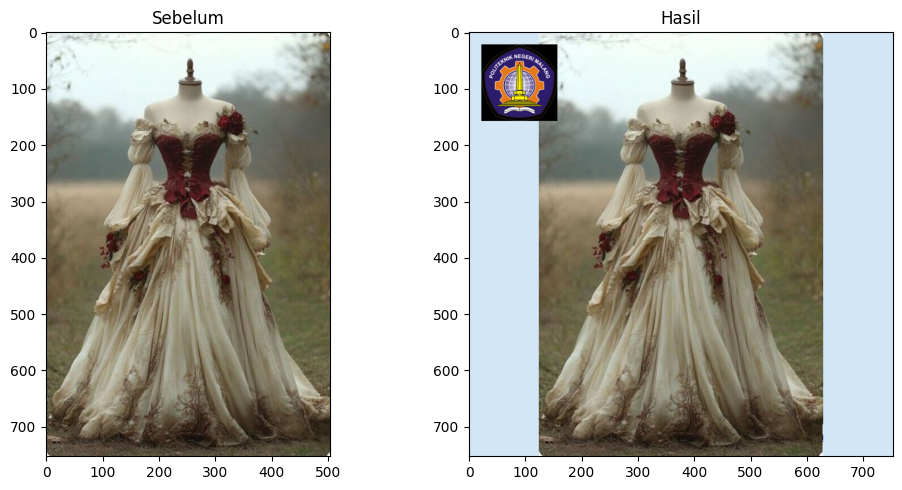

In [46]:
plt.figure(figsize=(10, 5))

# Tampilan Sebelum
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Sebelum')

# Tampilan Sesudah
plt.subplot(1, 2, 2)
plt.imshow(hasil_thumbnail)
plt.title('Hasil')

plt.tight_layout()
plt.show()

**Studi Kasus 1**: Panitia sebuah kegiatan perlu membubuhkan label identitas pada
ratusan foto dokumentasi. Foto berasal dari beberapa kamera dan ponsel,
sehingga ukurannya bermacam-macam. Label harus terlihat seimbang pada
semua foto tanpa disetel satu per satu. Fungsi yang sama dikenakan pada dua
citra berbeda ukuran. Tinggi bar dan ukuran huruf ikut menyesuaikan, sehingga
proporsinya tetap sama.

In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [10]:
from google.colab import files
uploaded = files.upload()

Saving Citra 1.jpeg to Citra 1.jpeg


In [11]:
from google.colab import files
uploaded = files.upload()

Saving Citra 2.jpeg to Citra 2.jpeg


In [12]:
img1 = cv.imread('Citra 1.jpeg')
img2 = cv.imread('Citra 2.jpeg')

In [13]:
img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

In [14]:
print("Ukuran citra 1: ", img1_rgb.shape)
print("Ukuran citra 2: ", img2_rgb.shape)

Ukuran citra 1:  (900, 1600, 3)
Ukuran citra 2:  (1600, 900, 3)


In [15]:
def tambah_label(img, teks):
    h, w = img.shape[:2]

    # Tinggi bar adaptif (8% dari tinggi)
    tinggi_bar = max(20, int(h * 0.08))

    # Ukuran font adaptif
    skala_font = max(0.5, min(w, h) / 500)
    tebal = max(1, int(skala_font * 1.5))

    # Buat salinan
    hasil = img.copy()

    # Gambar bar hitam di bawah
    cv.rectangle(hasil, (0, h - tinggi_bar), (w, h), (0, 0, 0), -1)

    # Tambahkan teks di tengah
    ukuran_teks = cv.getTextSize(teks, cv.FONT_HERSHEY_SIMPLEX, skala_font, tebal)[0]
    x = (w - ukuran_teks[0]) // 2
    y = h - tinggi_bar + (tinggi_bar + ukuran_teks[1]) // 2

    cv.putText(hasil, teks, (x, y), cv.FONT_HERSHEY_SIMPLEX,
               skala_font, (255, 255, 255), tebal, cv.LINE_AA)

    return hasil

In [16]:
img1_label = tambah_label(img1_rgb, "DOKUMENTASI PCVK - 2026")
img2_label = tambah_label(img2_rgb, "DOKUMENTASI PCVK - 2026")

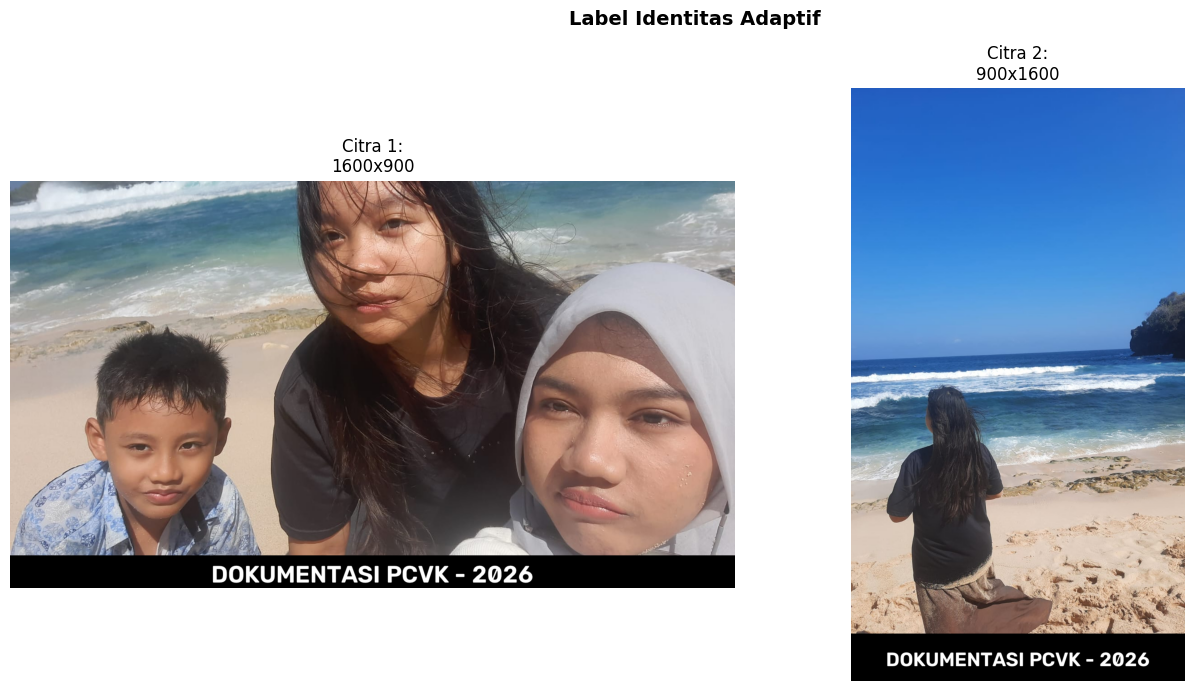

In [17]:
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(img1_label)
plt.title(f'Citra 1:\n{img1_rgb.shape[1]}x{img1_rgb.shape[0]}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img2_label)
plt.title(f'Citra 2:\n{img2_rgb.shape[1]}x{img2_rgb.shape[0]}')
plt.axis('off')

plt.suptitle('Label Identitas Adaptif', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**TUGAS PRAKTIKUM - Analisa**

Apakah proses mengecilkan resolusi citra secara ekstrem lalu memperbesarnya kembali ke ukuran semula akan mengubah nilai rata-rata intensitas piksel citra serta seberapa besar tingkat deviasi/kehilangan detailnya (*Mean Squared Error*)?

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Baca citra awal dalam skala abu-abu
img_original = cv.imread('FotoDiri.jpg', cv.IMREAD_GRAYSCALE)
h, w = img_original.shape

In [ ]:
# Perkecil citra ke ukuran 10% (downscale)
small_w, small_h = int(w * 0.1), int(h * 0.1)
img_small = cv.resize(img_original, (small_w, small_h))

In [ ]:
# Perbesar kembali ke dimensi awal (upscale)
img_restored = cv.resize(img_small, (w, h))

In [ ]:
# Perhitungan statistik menggunakan NumPy
mean_orig = np.mean(img_original)
mean_restored = np.mean(img_restored)
diff_mean = abs(mean_orig - mean_restored)
# Menghitung Mean Squared Error (MSE)
mse = np.mean((img_original.astype("float") - img_restored.astype("float")) ** 2)

In [ ]:
# Cetak output data
print(f"Resolusi Awal          : {w} x {h}")
print(f"Resolusi Downscale     : {small_w} x {small_h}")
print(f"Rata-rata Intensitas Asli       : {mean_orig:.4f}")
print(f"Rata-rata Intensitas Restorasi  : {mean_restored:.4f}")
print(f"Selisih Nilai Rata-rata         : {diff_mean:.4f}")
print(f"Nilai Error (MSE)               : {mse:.2f}")

Resolusi Awal          : 1280 x 720
Resolusi Downscale     : 128 x 72
Rata-rata Intensitas Asli       : 89.3749
Rata-rata Intensitas Restorasi  : 89.3566
Selisih Nilai Rata-rata         : 0.0183
Nilai Error (MSE)               : 41.78


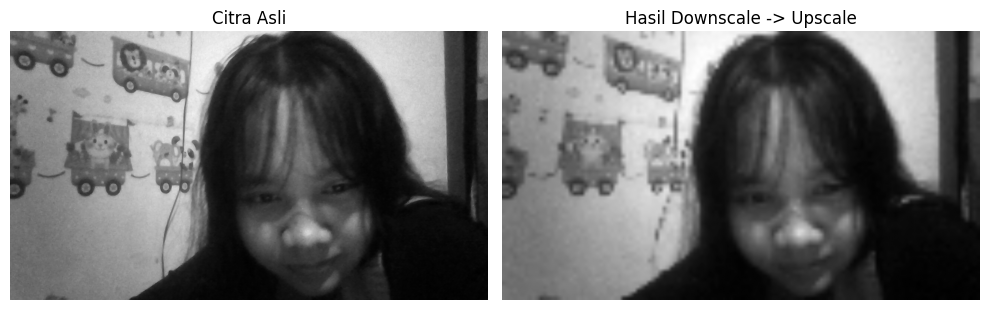

In [ ]:
# Tampilkan visualisasi perbandingan
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_original, cmap='gray')
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_restored, cmap='gray')
plt.title('Hasil Downscale -> Upscale')
plt.axis('off')

plt.tight_layout()
plt.show()

**TUGAS PRAKTIKUM - Penerapan**

1. Kombinasi Kanal Warna (Merah–Biru dan Hijau–Biru)

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
# Baca citra dan ubah ke RGB
img = cv.imread('Perpus.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

In [ ]:
# Kombinasi Merah-Biru (kanal Hijau di-nol-kan)
img_red_blue = img_rgb.copy()
img_red_blue[:, :, 1] = 0

In [ ]:
# Kombinasi Hijau-Biru (kanal Merah di-nol-kan)
img_green_blue = img_rgb.copy()
img_green_blue[:, :, 0] = 0

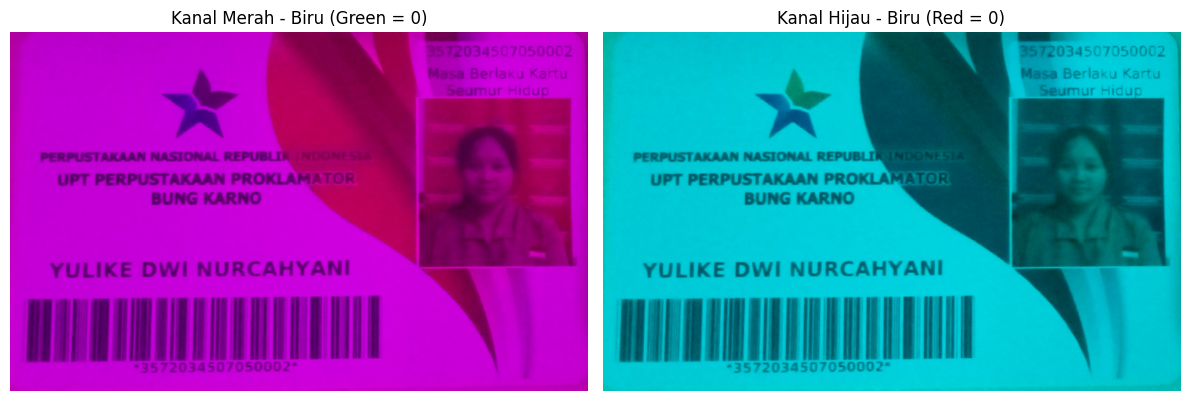

In [ ]:
# Tampilkan berdampingan dalam satu figure
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_red_blue)
plt.title('Kanal Merah - Biru (Green = 0)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_green_blue)
plt.title('Kanal Hijau - Biru (Red = 0)')
plt.axis('off')

plt.tight_layout()
plt.show()

2. Pencerminan Citra (Vertikal, Horizontal, Keduanya)

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
# Baca dan konversi citra ke RGB
img = cv.imread('Perpus.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

In [ ]:
# Operasi flip
flip_vertikal = cv.flip(img_rgb, 0)     # flipCode 0: vertikal
flip_horizontal = cv.flip(img_rgb, 1)   # flipCode 1: horizontal
flip_keduanya = cv.flip(img_rgb, -1)    # flipCode -1: vertikal & horizontal

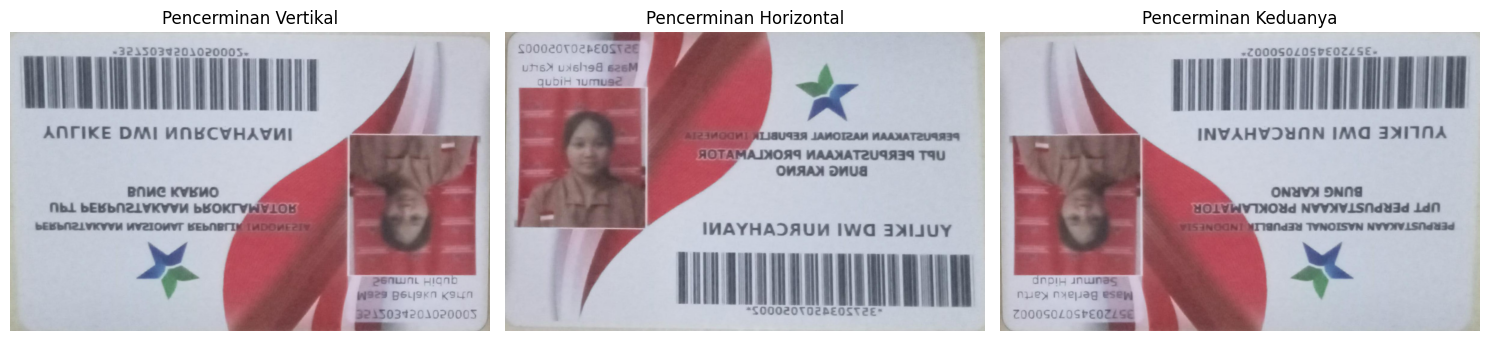

In [ ]:
# Tampilkan dalam 3 subplot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(flip_vertikal)
plt.title('Pencerminan Vertikal')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(flip_horizontal)
plt.title('Pencerminan Horizontal')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(flip_keduanya)
plt.title('Pencerminan Keduanya')
plt.axis('off')

plt.tight_layout()
plt.show()

3. Rectangle, Circle, dan Teks Nama pada Foto Pribadi

In [ ]:
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
# Baca foto aktivitas dan ubah ke RGB
foto = cv.imread('FotoDiri.jpg')
foto_rgb = cv.cvtColor(foto, cv.COLOR_BGR2RGB)

In [ ]:
# Dapatkan tinggi (h) dan lebar (w) gambar secara dinamis
h, w, _ = foto_rgb.shape

In [ ]:
# Menggunakan koordinat relatif (%) agar pas
pt1 = (int(w * 0.32), int(h * 0.57))  # Sudut kiri atas badan
pt2 = (int(w * 0.98), int(h * 0.99))  # Sudut kanan bawah badan
cv.rectangle(foto_rgb, pt1=pt1, pt2=pt2, color=(255, 0, 0), thickness=3)

array([[[ 95, 108,  90],
        [ 90, 103,  83],
        [ 90, 102,  80],
        ...,
        [100, 129, 143],
        [101, 129, 143],
        [100, 128, 142]],

       [[ 92, 105,  87],
        [ 90, 103,  83],
        [ 91, 103,  81],
        ...,
        [100, 129, 143],
        [101, 129, 143],
        [101, 129, 143]],

       [[ 87, 102,  83],
        [ 89, 104,  83],
        [ 92, 106,  83],
        ...,
        [ 99, 127, 141],
        [100, 128, 142],
        [100, 128, 142]],

       ...,

       [[103, 110, 116],
        [102, 111, 116],
        [101, 110, 117],
        ...,
        [ 12,  13,  15],
        [ 15,  16,  18],
        [ 16,  17,  19]],

       [[109, 114, 118],
        [107, 115, 118],
        [106, 113, 119],
        ...,
        [ 14,  15,  17],
        [ 16,  17,  19],
        [ 17,  18,  20]],

       [[109, 114, 118],
        [110, 115, 119],
        [107, 114, 120],
        ...,
        [ 15,  16,  18],
        [ 16,  17,  19],
        [ 16,  17,  19]]

In [ ]:
# Gambar CIRCLE di area wajah
center = (int(w * 0.61), int(h * 0.48))
radius = int(h * 0.34)
cv.circle(foto_rgb, center=center, radius=radius, color=(0, 255, 0), thickness=3)

array([[[ 95, 108,  90],
        [ 90, 103,  83],
        [ 90, 102,  80],
        ...,
        [100, 129, 143],
        [101, 129, 143],
        [100, 128, 142]],

       [[ 92, 105,  87],
        [ 90, 103,  83],
        [ 91, 103,  81],
        ...,
        [100, 129, 143],
        [101, 129, 143],
        [101, 129, 143]],

       [[ 87, 102,  83],
        [ 89, 104,  83],
        [ 92, 106,  83],
        ...,
        [ 99, 127, 141],
        [100, 128, 142],
        [100, 128, 142]],

       ...,

       [[103, 110, 116],
        [102, 111, 116],
        [101, 110, 117],
        ...,
        [ 12,  13,  15],
        [ 15,  16,  18],
        [ 16,  17,  19]],

       [[109, 114, 118],
        [107, 115, 118],
        [106, 113, 119],
        ...,
        [ 14,  15,  17],
        [ 16,  17,  19],
        [ 17,  18,  20]],

       [[109, 114, 118],
        [110, 115, 119],
        [107, 114, 120],
        ...,
        [ 15,  16,  18],
        [ 16,  17,  19],
        [ 16,  17,  19]]

In [ ]:
# Tambahkan teks di kanan atas
font = cv.FONT_HERSHEY_DUPLEX
text = 'Yulike Dwi Nurcahyani'

# Hitung ukuran teks secara dinamis agar pas menempel di batas kanan atas
font_scale = 0.8
thickness = 2
(text_w, text_h), _ = cv.getTextSize(text, font, font_scale, thickness)

# Titik koordinat x digeser dari tepi kanan (dikurangi margin 20 piksel)
text_x = w - text_w - 20
text_y = text_h + 30

cv.putText(foto_rgb, text=text, org=(text_x, text_y),
           fontFace=font, fontScale=font_scale, color=(255, 255, 0),
           thickness=thickness, lineType=cv.LINE_AA)

array([[[ 95, 108,  90],
        [ 90, 103,  83],
        [ 90, 102,  80],
        ...,
        [100, 129, 143],
        [101, 129, 143],
        [100, 128, 142]],

       [[ 92, 105,  87],
        [ 90, 103,  83],
        [ 91, 103,  81],
        ...,
        [100, 129, 143],
        [101, 129, 143],
        [101, 129, 143]],

       [[ 87, 102,  83],
        [ 89, 104,  83],
        [ 92, 106,  83],
        ...,
        [ 99, 127, 141],
        [100, 128, 142],
        [100, 128, 142]],

       ...,

       [[103, 110, 116],
        [102, 111, 116],
        [101, 110, 117],
        ...,
        [ 12,  13,  15],
        [ 15,  16,  18],
        [ 16,  17,  19]],

       [[109, 114, 118],
        [107, 115, 118],
        [106, 113, 119],
        ...,
        [ 14,  15,  17],
        [ 16,  17,  19],
        [ 17,  18,  20]],

       [[109, 114, 118],
        [110, 115, 119],
        [107, 114, 120],
        ...,
        [ 15,  16,  18],
        [ 16,  17,  19],
        [ 16,  17,  19]]

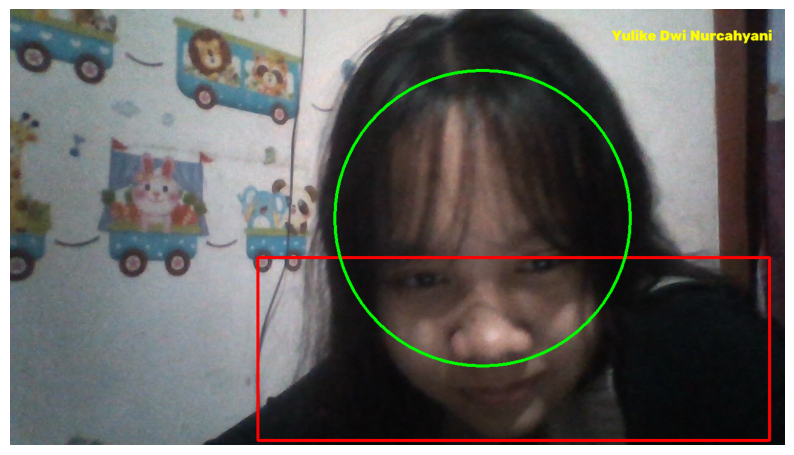

In [ ]:
# Tampilkan hasilnya
plt.figure(figsize=(10, 8))
plt.imshow(foto_rgb)
plt.axis('off')
plt.show()

5. Apakah img.shape ikut berubah?

   Tidak. Nilai img.shape tetap sama persis, tidak mengalami perubahan sedikit pun sebelum maupun sesudah ditampilkan dengan figsize yang besar.
* Perbedaan mengubah ukuran citra vs mengubah ukuran
tampilan:

1. Mengubah ukuran citra (misalnya via cv.resize):
Proses ini memodifikasi data array piksel citra secara langsung di memori. Dimensi array (shape) dan jumlah total pikselnya berubah nyata lewat proses interpolasi (menambah atau membuang piksel). Jika ukuran diperkecil atau diperbesar, resolusi data asli citra tersebut benar-benar berganti.
2. Mengubah ukuran tampilan (misalnya via parameter figsize pada Matplotlib):
Proses ini hanya mengubah ukuran fisik kanvas atau jendela grafik saat dirender di layar (dalam satuan inci visual). Data citra, struktur matriks, nilai piksel, dan shape di memori tidak tersentuh sama sekali; gambar hanya tampak lebih besar atau lebih kecil secara visual bagi pengguna.


Shape awal citra: (996, 1600, 3)


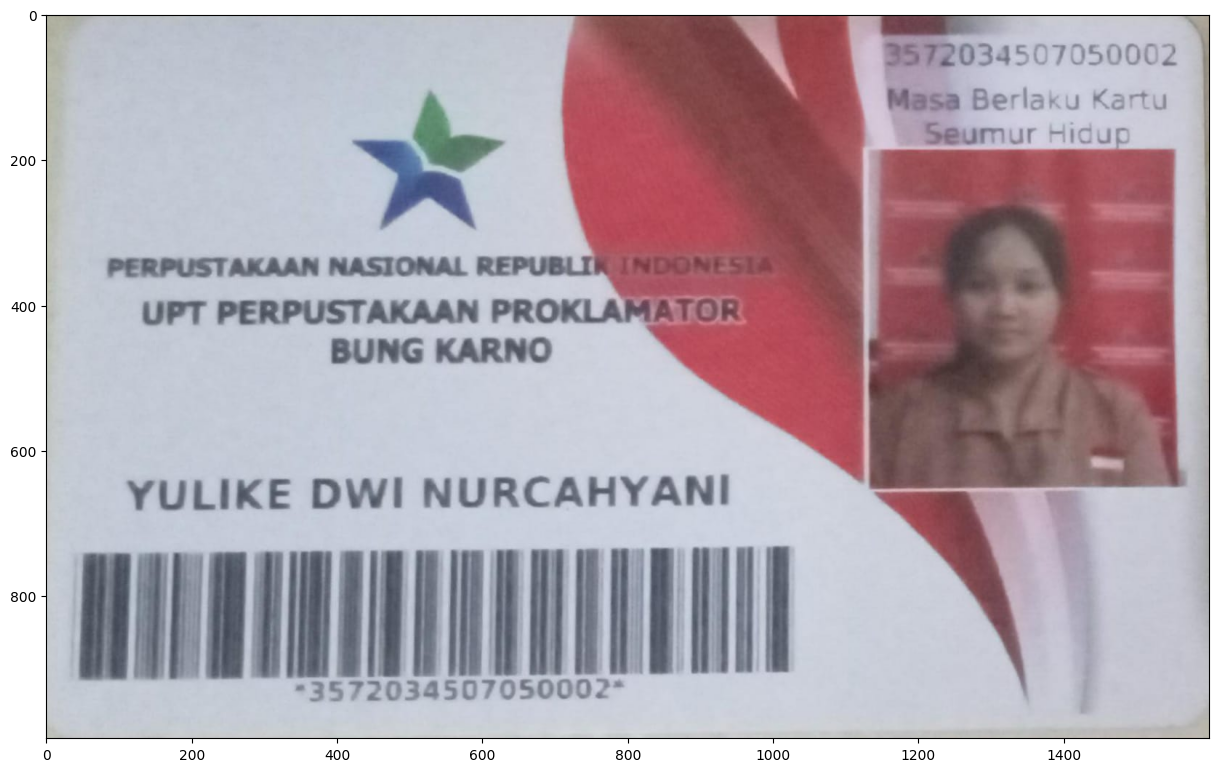

Shape citra setelah figsize diperbesar: (996, 1600, 3)


In [ ]:
print("Shape awal citra:", img.shape)

fig = plt.figure(figsize=(15, 15))
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
plt.show()

print("Shape citra setelah figsize diperbesar:", img.shape)

4. Kedua gambar menampilkan warna sebenarnya. Baik skimage.io.imread() maupun cv.cvtColor(img, cv.COLOR_BGR2RGB) menghasilkan susunan kanal yang sama, yaitu RGB.
Citra yang kanalnya tertukar adalah citra asli hasil cv.imread() sebelum dikonversi, karena menggunakan format BGR.

In [ ]:
from skimage import io
import cv2 as cv
import matplotlib.pyplot as plt

In [ ]:
# Baca dengan skimage (output: RGB)
img_skimage = io.imread('Perpus.jpeg')

In [ ]:
# Baca dengan OpenCV (output: BGR) lalu dikonversi ke RGB
img_cv = cv.imread('Perpus.jpeg')
img_cv_rgb = cv.cvtColor(img_cv, cv.COLOR_BGR2RGB)

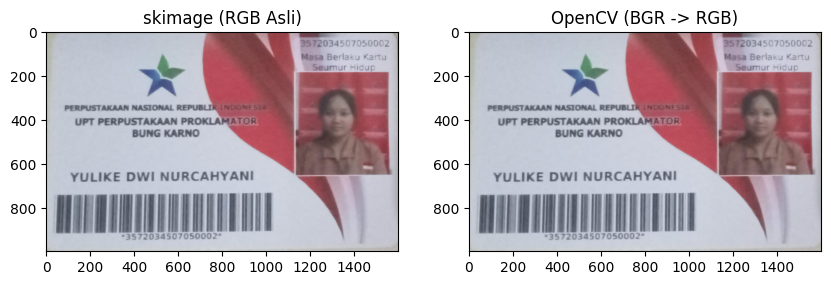

In [ ]:
# Visualisasi berdampingan via Matplotlib
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_skimage)
plt.title('skimage (RGB Asli)')

plt.subplot(1, 2, 2)
plt.imshow(img_cv_rgb)
plt.title('OpenCV (BGR -> RGB)')
plt.show()

In [ ]:
# Pembuktian nilai piksel
print("Nilai piksel (50, 50) skimage        :", img_skimage[50, 50])
print("Nilai piksel (50, 50) cv2 BGR to RGB :", img_cv_rgb[50, 50])
print("Nilai piksel (50, 50) cv2 asli (BGR) :", img_cv[50, 50])

Nilai piksel (50, 50) skimage        : [191 196 200]
Nilai piksel (50, 50) cv2 BGR to RGB : [191 196 200]
Nilai piksel (50, 50) cv2 asli (BGR) : [200 196 191]


3. Kegunaan cv2_imshow:
Modul tambalan (patch) resmi dari Colab untuk merender gambar array NumPy secara inline langsung di output cell notebook tanpa memerlukan window GUI desktop.
* Alasan cv2.imshow() bawaan tidak bisa digunakan di Colab:
Fungsi asli cv2.imshow() memerlukan sistem windowing sistem operasi desktop (seperti X11 di Linux atau Window Manager) untuk membuka jendela popup (GUI window). Karena Google Colab berjalan di atas server cloud berbasis headless Linux tanpa layar monitor fisik atau antarmuka GUI, pemanggilan cv2.imshow() akan menyebabkan proses crash (segmentation fault atau kernel terputus). Oleh sebab itu, fungsi tersebut dinonaktifkan di lingkungan Colab.


2. Penampilannya tidak berbeda. Keduanya sama-sama tampak hitam pekat secara visual karena seluruh elemen array bernilai 0 (nilai min = 0 dan max = 0).
* Ukurannya berbeda 2 kali lipat.
  * int16 menggunakan 16 bit = 2 byte per elemen.
    Ukuran total = 300 x 300 x 3 x 2 = 540.000 bytes.
  * int32 menggunakan 32 bit = 4 byte per elemen.
    Ukuran total = 300 x 300 x 3 x 4 = 1.080.000 bytes.

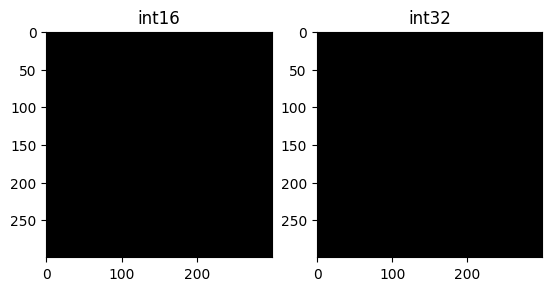

In [ ]:
# Menampilkan kanvas
plt.subplot(1, 2, 1)
plt.imshow(canvas_int16)
plt.title("int16")
plt.subplot(1, 2, 2)
plt.imshow(canvas_int32)
plt.title("int32")
plt.show()

In [ ]:
# Perbandingan atribut
print(f"Kanvas 1 -> dtype: {canvas_int16.dtype}, min: {canvas_int16.min()}, max: {canvas_int16.max()}, nbytes: {canvas_int16.nbytes} bytes")
print(f"Kanvas 2 -> dtype: {canvas_int32.dtype}, min: {canvas_int32.min()}, max: {canvas_int32.max()}, nbytes: {canvas_int32.nbytes} bytes")

Kanvas 1 -> dtype: int16, min: 0, max: 0, nbytes: 540000 bytes
Kanvas 2 -> dtype: int32, min: 0, max: 0, nbytes: 1080000 bytes


In [ ]:
# Kanvas int16 dan int32
canvas_int16 = np.zeros(shape=(300, 300, 3), dtype=np.int16)
canvas_int32 = np.zeros(shape=(300, 300, 3), dtype=np.int32)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

1. Penyebab perbedaan tampilan:
OpenCV membaca citra dalam susunan kanal warna BGR (Blue, Green, Red), sedangkan plt.imshow() dari Matplotlib mengasumsikan susunan warna citra adalah RGB (Red, Green, Blue). Karena kanal B dan R tertukar penafsirannya oleh Matplotlib, warna citra yang dihasilkan tampak anomali (misalnya warna kulit atau bidang merah berubah menjadi kebiruan). Sebaliknya, cv2_imshow() dirancang khusus oleh Google Colab untuk langsung menampilkan array BGR sebagaimana adanya.

In [ ]:
# Bukti nilai piksel pada koordinat yang sama, misal (y=50, x=50)
pixel_val = img[50, 50]
print(f"Nilai piksel pada koordinat (50, 50) dalam format BGR: {pixel_val}")
print(f"Kanal B (Biru): {pixel_val[0]}, Kanal G (Hijau): {pixel_val[1]}, Kanal R (Merah): {pixel_val[2]}")

Nilai piksel pada koordinat (50, 50) dalam format BGR: [200 196 191]
Kanal B (Biru): 200, Kanal G (Hijau): 196, Kanal R (Merah): 191



Tampilan plt.imshow (tanpa konversi):


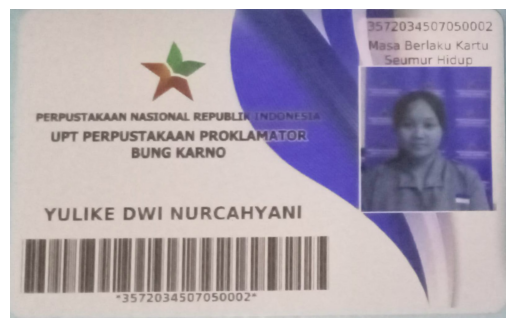

In [ ]:
# Tampilkan dengan plt.imshow tanpa konversi warna
print("\nTampilan plt.imshow (tanpa konversi):")
plt.imshow(img)
plt.axis('off')
plt.show()

Tampilan cv2_imshow (OpenCV patch):


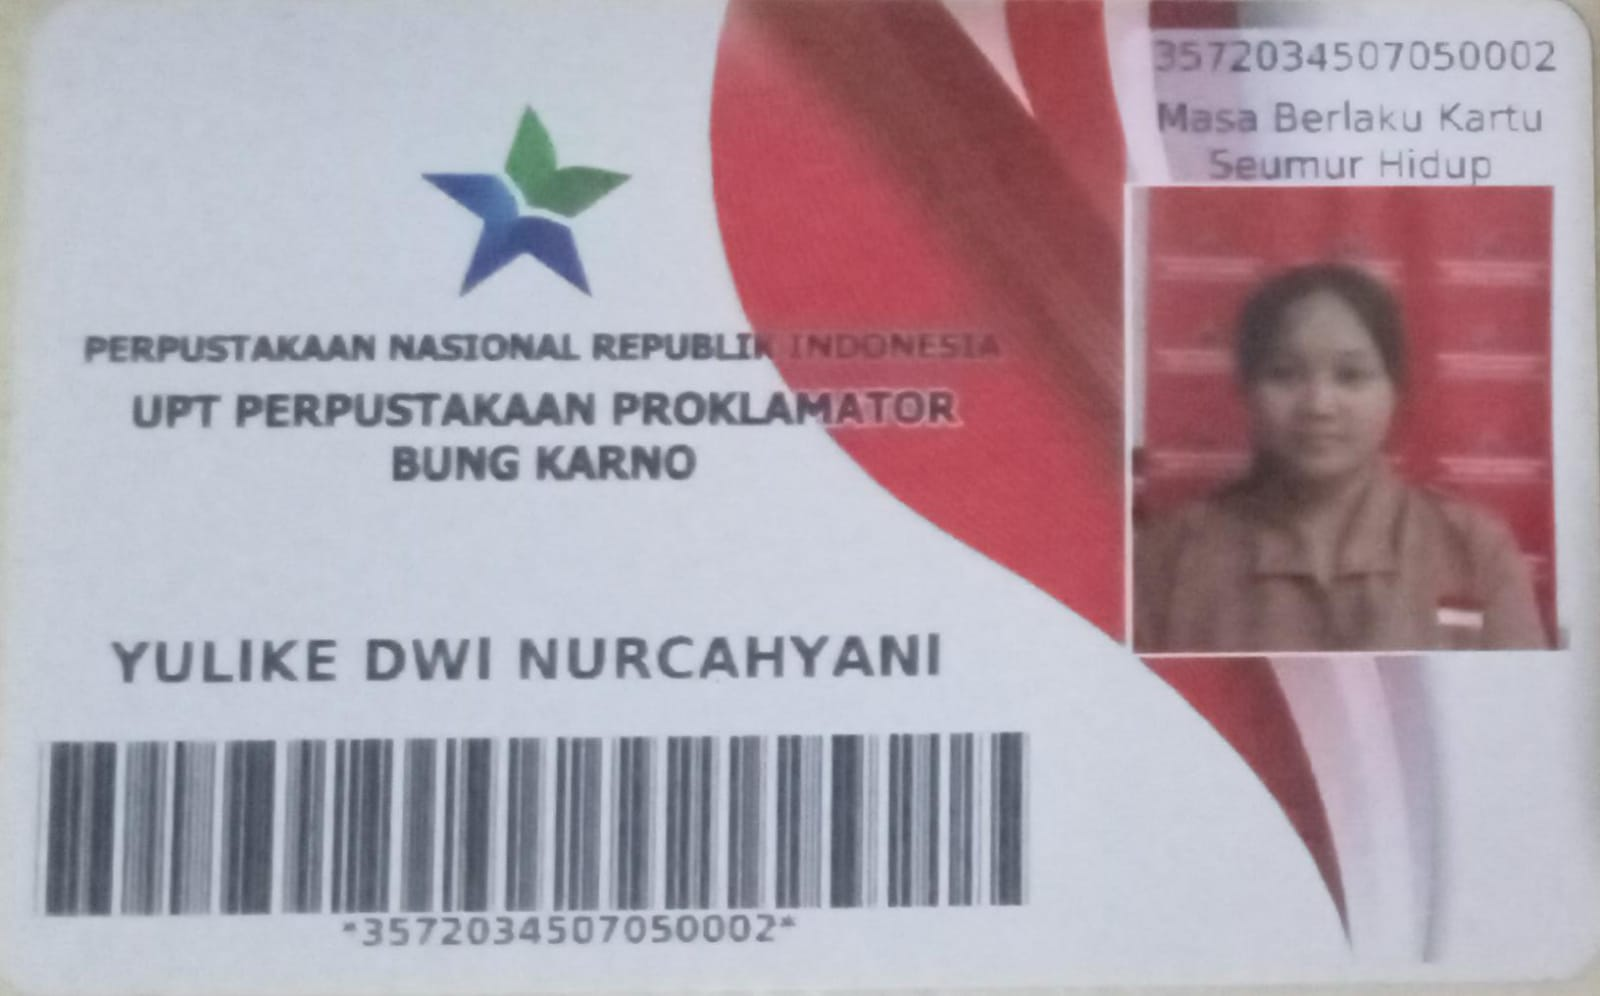

In [ ]:
# Tampilkan dengan cv2_imshow
print("Tampilan cv2_imshow (OpenCV patch):")
cv2_imshow(img)

In [ ]:
img = cv.imread('Perpus.jpeg')

In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

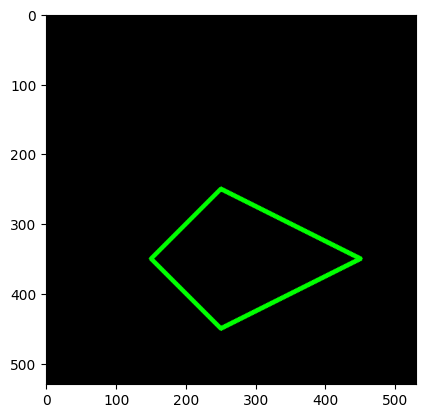

In [ ]:
cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)

In [ ]:
pts = vertices.reshape((-1,1,2)) # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yg mewakili R, G, dan B
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

In [ ]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

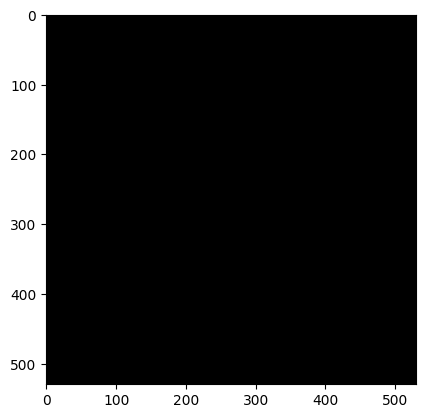

In [ ]:
black_img2=np.zeros(shape=(530,530,3),dtype=np.int32)
plt.imshow(black_img2)

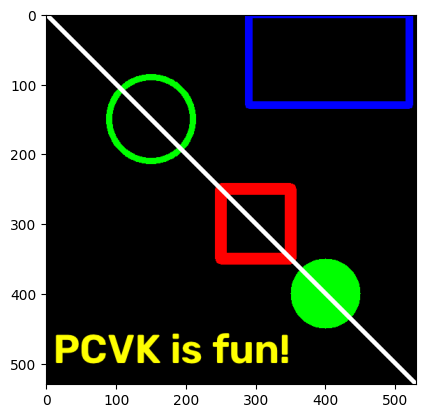

In [ ]:
black_img = black_img.astype(np.uint8)

font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img, text='PCVK is fun!', org=(10,500), fontFace=font, fontScale=2,
           color=(255,255,0), thickness=3, lineType=cv.LINE_AA)
plt.imshow(black_img)

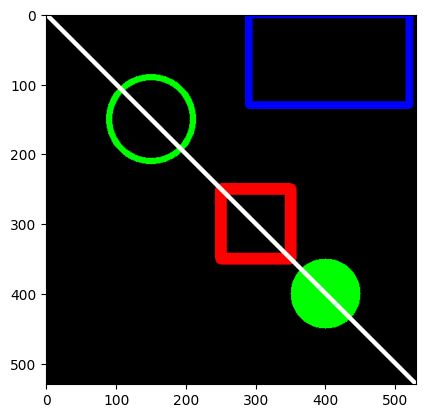

In [ ]:
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

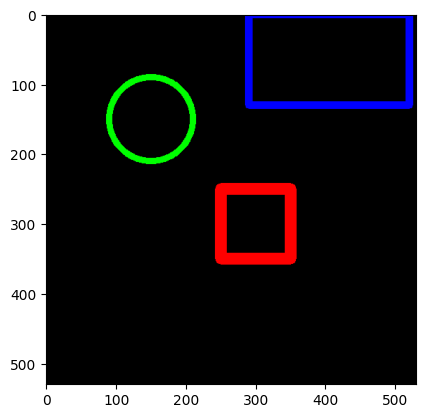

In [ ]:
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

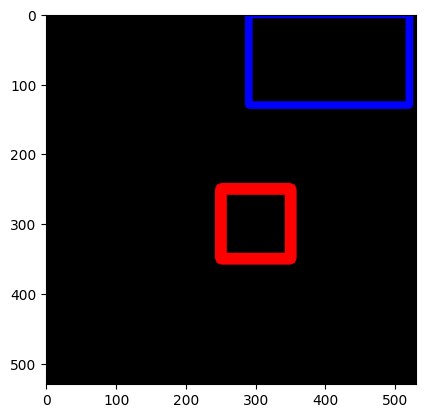

In [ ]:
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

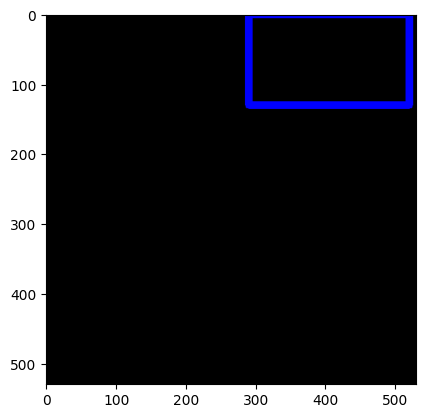

In [ ]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

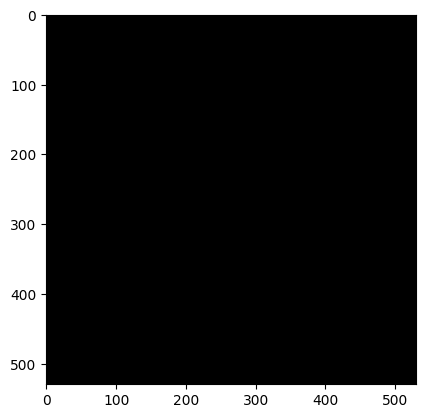

In [ ]:
black_img = np.zeros(shape=(530,530,3),dtype=np.uint8)
plt.imshow(black_img)

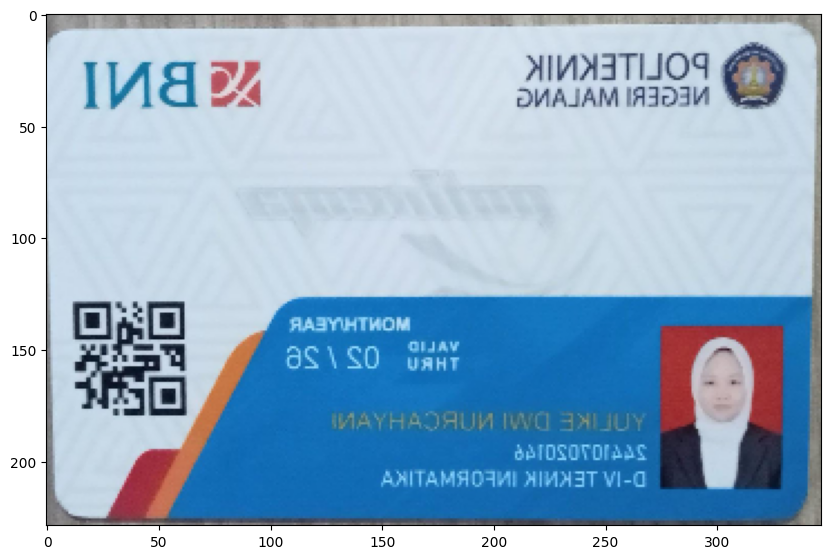

In [ ]:
imgFlip=cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

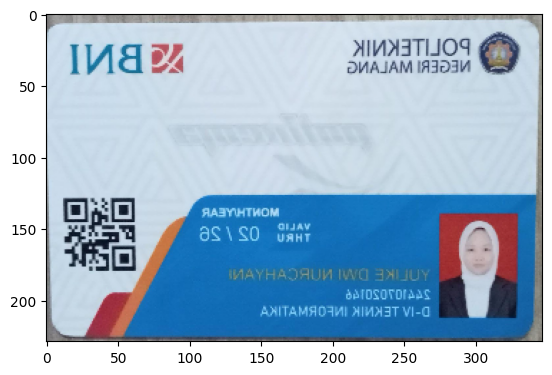

In [ ]:
imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

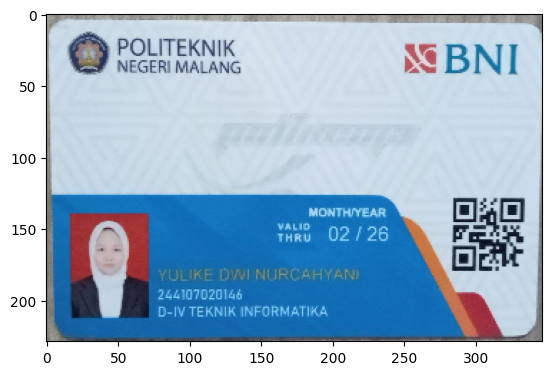

In [ ]:
imgRGB = cv.cvtColor(img, cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

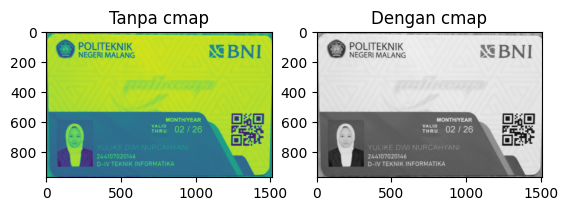

In [ ]:
img_gray = cv.imread('ktmIke.jpg', cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

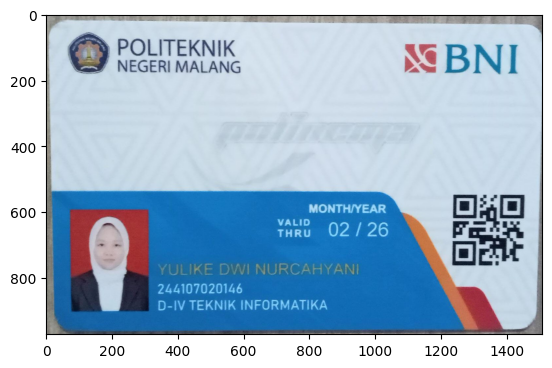

In [ ]:
img = cv.imread('ktmIke.jpg')
plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB)) #konversi channel BGR -> RGB
plt.show()

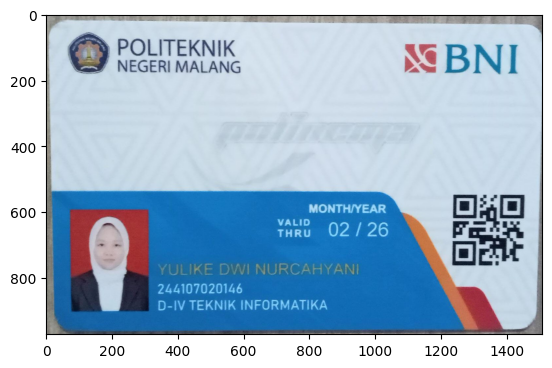

In [ ]:
img = cv.imread('ktmIke.jpg')
img2 = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img2)

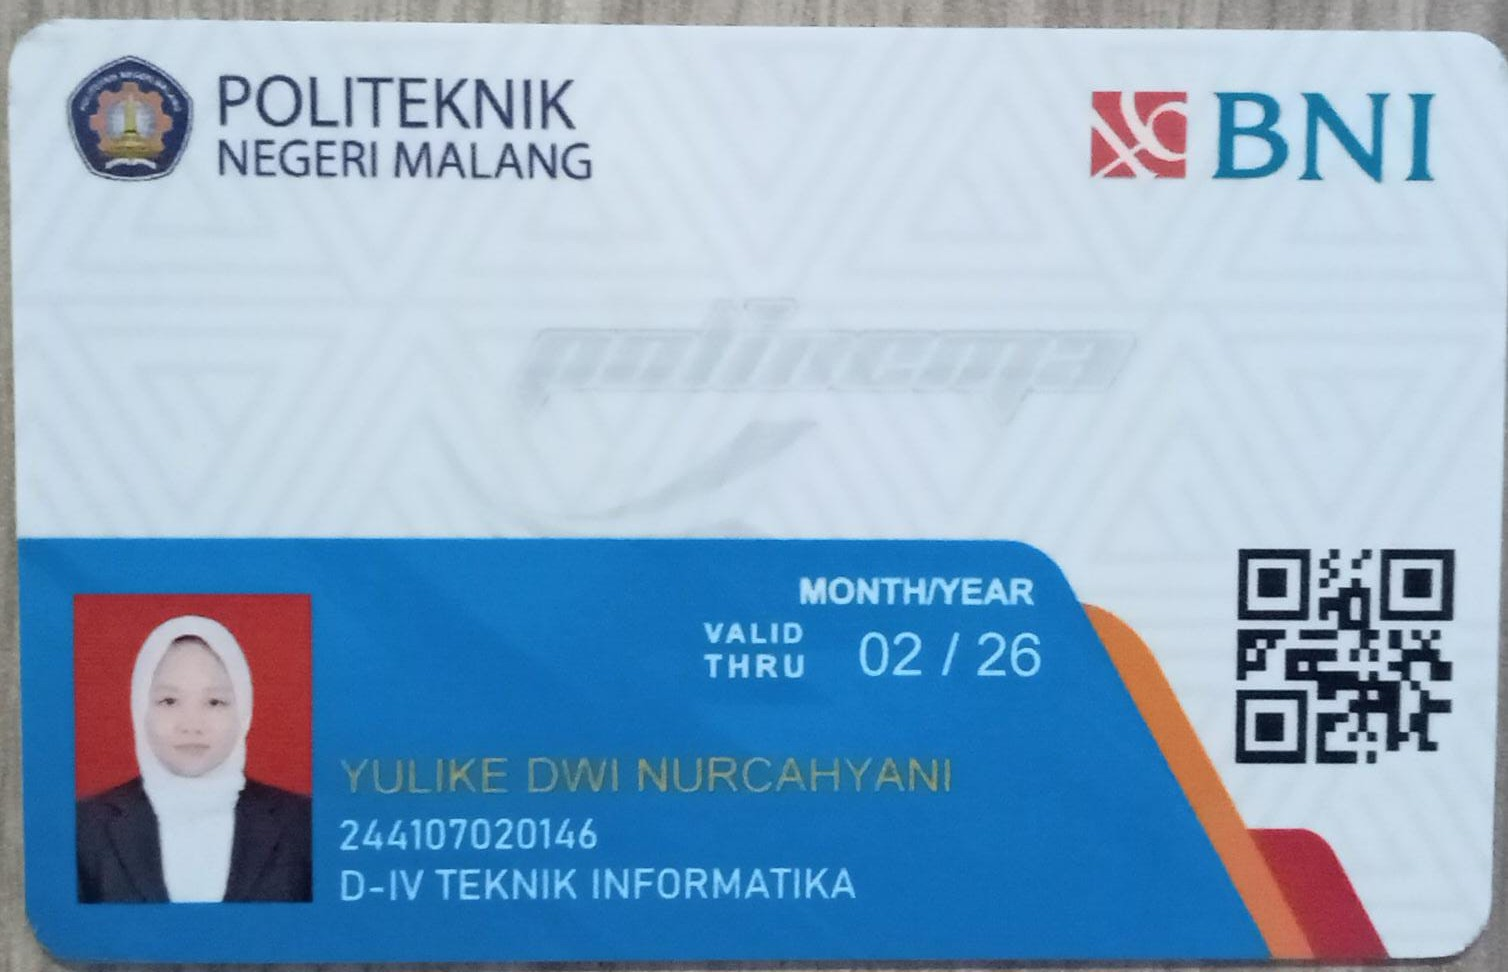

Resolusi gambar:  1508  x  972


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('ktmIke.jpg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])